## Physical insight into the optimized PVs

## 1) Setup

In [46]:
%run -i imports.py
import pandas as pd
import numpy as np
%matplotlib inline
data_tag = 'M2'
target_variables_indices = [0, 5, 6, 7, 8, 9, 10, 13, 14, 15, 17, 20, 23, 24, 25, 26]
pure_streams = True #DO NOT modify it, unless you want to perform a "non-trainable pure streams analysis" (Refer to Section 3.4. The impact of training data preprocessing of https://doi.org/10.1016/j.combustflame.2025.114152)
pure_streams_prefix = 'tps'
data_type = 'FPF'
%run -i ../scripts/fpf-load-data.py
import matplotlib.pyplot as plt

Python==3.10.13

numpy==1.26.2
pandas==2.1.3
scipy==1.11.4
scikit-learn==1.3.2
PCAfold==2.2.0

Using: T, H2, H, O, OH, H2O, O2, NH3, NH2, NO2, NH, NO, N2O, CO2, CO, CH4 as target state variables at the decoder output.

9303 observations
56 state variables


<Figure size 640x480 with 0 Axes>

In [47]:
def populate_weights_matrix(model_weights_filename, random_seeds_list): #added

    Yi = state_space[:, 5:]

    n_species = Yi.shape[1]

    weights_collected = np.zeros((len(random_seeds_list), n_species))

    for i, random_seed in enumerate(random_seeds_list):

        hf = h5py.File(model_weights_filename + str(random_seed) + '.h5', 'r')

        current_weights = np.array(hf.get('0'))
        hf.close()
        
        current_weights = (current_weights/ np.max(current_weights))
        
        weights_collected[i, :] = current_weights.ravel()

    return weights_collected

In [48]:
def plot_violins(weights_collected): #added

    fig, ax = plt.subplots(figsize=(10, 3))

    n_species = weights_collected.shape[1]
    xrange = np.arange(n_species)

    violin_parts = ax.violinplot(weights_collected,positions=xrange,widths=0.8)

    ax.scatter(xrange,np.median(weights_collected, axis=0), s=20,c='k')

    ax.set_xticks(xrange)
    ax.set_xticklabels(tex_names,rotation=90,fontsize=10)

    ax.tick_params(axis='y', labelsize=18)

    ax.set_ylabel(r'$w_i$ [$-$]',fontsize=20)

    ax.grid(alpha=0.3, zorder=1)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])

    for pc in violin_parts['bodies']:
        pc.set_facecolor('red')
        pc.set_edgecolor('red')

    for partname in ('cbars', 'cmins', 'cmaxes'):
        vp = violin_parts[partname]
        vp.set_edgecolor('k')
        vp.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

## 2) Distribution of the scaled mass fraction

In [ ]:
### Select the seed you want to analyse
random_seeds_list = [0]

In [50]:
tex_names = tex_names[5::]

In [51]:
### Adapt to your own best-model-weights.h5 file
model_weights_filename = '../scripts/f-PV-' + pure_streams_prefix + '-FPF-M2-target-T-H2-H-O-OH-H2O-O2-NH3-NH2-NO2-NH-NO-N2O-CO2-CO-CH4-RandomNormal-e-300000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-best-model-weights-rs-'

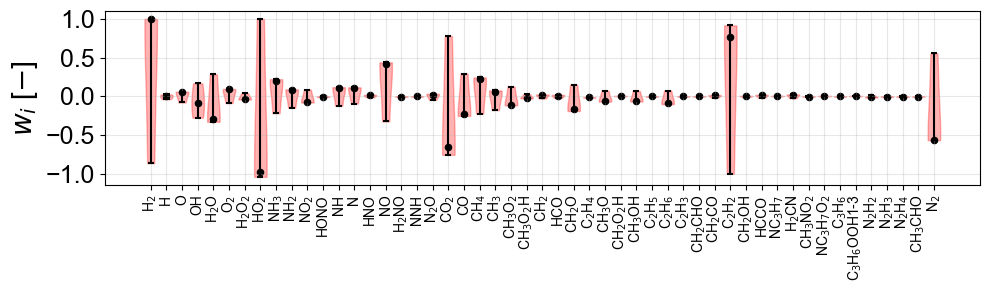

In [52]:
weights_collected = populate_weights_matrix(model_weights_filename, random_seeds_list)
plot_violins(weights_collected)

In [ ]:
Yi = state_space[:, 5:]

n_species = Yi.shape[1]


# Get the corresponding species names
species_names = np.array(tex_names)

weights_collected = np.zeros((len(random_seeds_list), n_species))

for i, random_seed in enumerate(random_seeds_list):

    hf = h5py.File(model_weights_filename + str(random_seed) + '.h5', 'r')

    current_weights = np.array(hf.get('0'))
    hf.close()
        
    current_weights = (current_weights/ np.max(current_weights))
        

weights_collected[i, :] = current_weights.ravel()

weights_collected_flat = np.asarray(weights_collected).ravel()

species_names = np.array(tex_names)

# Round weights
weights = np.round(weights_collected_flat, 3)

# Create the table
table_weights_collected = pd.DataFrame(
    [weights],
    index=[r'Weights $w_i$'],
    columns=species_names
)

# Give the index a name
table_weights_collected.index.name = 'Species'



species = [
    name.replace('$', '')
        .replace(r'\*', '')
        .replace(r'\_', '')
        .replace('*', '')
        .replace('_', '')
    for name in species_names
]


# Save as CSV
table_weights_collected.to_csv(
    'table_weights_collected_all.csv',
    index=True,
    index_label='Species'
)

# Prepare table including the index as the first column
table_data = table_weights_collected.reset_index()

# Create PNG
fig, ax = plt.subplots(
    figsize=(max(6, len(table_data.columns) * 1.2), 2.5)
)

ax.axis('off')

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    rowLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

plt.tight_layout()

plt.savefig(
    'table_weights_collected_all.png',
    dpi=300,
    bbox_inches='tight'
)

plt.close()

print(f"species = {species}")

print(f"weights = {weights}")


ValueError: 51 columns passed, passed data had 153 columns

In [45]:
# Keep weights outside the interval [-0.1, 0.1]
mask = (weights_collected_flat < -0.1) | (weights_collected_flat > 0.1)

# Get the corresponding species names
species_names = np.array(tex_names)[mask]

# Get the corresponding weights
selected_weights = weights_collected_flat[mask]

# Round weights
selected_weights = np.round(selected_weights, 3)

# Create the table
table_weights_collected = pd.DataFrame(
    [selected_weights],
    index=[r'Weights $w_i$'],
    columns=species_names
)

# Give the index a name
table_weights_collected.index.name = 'Species'



species = [
    name.replace('$', '')
        .replace(r'\*', '')
        .replace(r'\_', '')
        .replace('*', '')
        .replace('_', '')
    for name in species_names
]

print(f"species = {species}")

weights_list = selected_weights.tolist()

print(f"weights = {weights_list}")


# Save as CSV
table_weights_collected.to_csv(
    'table_weights_collected.csv',
    index=True,
    index_label='Species'
)

# Prepare table including the index as the first column
table_data = table_weights_collected.reset_index()

# Create PNG
fig, ax = plt.subplots(
    figsize=(max(6, len(table_data.columns) * 1.2), 2.5)
)

ax.axis('off')

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    rowLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

plt.tight_layout()

plt.savefig(
    'table_weights_collected.png',
    dpi=300,
    bbox_inches='tight'
)

plt.close()

species = ['H2', 'OH', 'H2O', 'HO2', 'NH3', 'NH2', 'NH', 'NO', 'CO2', 'CO', 'CH4', 'CH3', 'CH3O2', 'CH2O', 'C2H2', 'N2']
weights = [-0.863, 0.168, 0.285, 1.0, -0.217, -0.146, -0.122, -0.324, 0.78, 0.294, -0.225, -0.178, 0.125, 0.152, -0.999, 0.554]
